# Fase 2.3 — Experimento de Ruido Controlado
**Objetivo:** Evaluar la robustez de los modelos SVM y Random Forest ante ruido gaussiano agregado a las features.

Se agrega ruido con σ ∈ {0.00, 0.05, 0.10, 0.20} y se mide la degradación del rendimiento.

- σ = 0.00 → sin ruido (línea base)
- σ = 0.05 → ruido pequeño (variación normal entre laboratorios)
- σ = 0.10 → ruido moderado (equipo con calibración regular)
- σ = 0.20 → ruido fuerte (condiciones adversas o datos ruidosos)

## 0. Imports y configuración

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone


Librerías cargadas correctamente ✓


## 1. Carga y preparación de datos

In [2]:
df = pd.read_csv(r"../data_test/NHANES_2017_2020_labeled_diseases.csv")

print(f'Shape del dataset: {df.shape}')
print(f'\nDistribución de clases:')
print(df['condition'].value_counts())

Shape del dataset: (4812, 11)

Distribución de clases:
condition
healthy             3766
borderline           410
thalassemia          347
thrombocytopenia     204
anemia                85
Name: count, dtype: int64


In [3]:
TARGET_COL = 'condition'

X = df.drop(columns=[TARGET_COL])
X = X.select_dtypes(include=[np.number])

le = LabelEncoder()
y  = le.fit_transform(df[TARGET_COL])

# Partición fija 70/30 — misma que en Fase 2.2 para comparabilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f'Features   : {X.shape[1]}')
print(f'Train size : {len(y_train)}')
print(f'Test size  : {len(y_test)}')
print(f'Clases     : {list(le.classes_)}')

Features   : 10
Train size : 3368
Test size  : 1444
Clases     : ['anemia', 'borderline', 'healthy', 'thalassemia', 'thrombocytopenia']


## 2. Definición de modelos

In [ ]:
pipe_svm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])

pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

modelos = {
    'SVM (RBF)'    : pipe_svm,
    'Random Forest': pipe_rf
}



Modelos definidos ✓


## 3. Entrenamiento con datos limpios (sin ruido)

Los modelos se entrenan **una sola vez** con los datos de entrenamiento limpios.
El ruido se agrega **únicamente al conjunto de prueba** para simular datos ruidosos en producción.

In [ ]:
modelos_entrenados = {}

for nombre, pipeline in modelos.items():
    pipe_copy = clone(pipeline)
    pipe_copy.fit(X_train, y_train)
    modelos_entrenados[nombre] = pipe_copy
    print(f'{nombre} entrenado con datos limpios')

✓ SVM (RBF) entrenado con datos limpios
✓ Random Forest entrenado con datos limpios


## 4. Experimento de ruido controlado

Para cada nivel de σ se agrega ruido gaussiano N(0, σ) a todas las features del conjunto de prueba.
Se evalúan los modelos ya entrenados sobre estos datos ruidosos.

In [ ]:
NIVELES_RUIDO = [0.00, 0.05, 0.10, 0.20]
N_REPETICIONES = 30   # Para cada sigma, repetir 30 veces y promediar (reduce varianza del ruido)

resultados = []  # Lista de dicts con todos los resultados

np.random.seed(42)

for sigma in NIVELES_RUIDO:
    print(f'\nProbando σ = {sigma}...')
    
    # Para sigma=0 no hace falta repetir
    reps = 1 if sigma == 0.0 else N_REPETICIONES
    
    scores_por_modelo = {nombre: {'acc': [], 'f1_mac': [], 'f1_w': []} for nombre in modelos}
    
    for rep in range(reps):
        # Agregar ruido gaussiano al test set
        ruido = np.random.normal(loc=0.0, scale=sigma, size=X_test.shape)
        X_test_ruidoso = X_test.copy().values + ruido
        X_test_ruidoso = pd.DataFrame(X_test_ruidoso, columns=X_test.columns)
        
        for nombre, modelo in modelos_entrenados.items():
            y_pred = modelo.predict(X_test_ruidoso)
            
            scores_por_modelo[nombre]['acc'].append(accuracy_score(y_test, y_pred))
            scores_por_modelo[nombre]['f1_mac'].append(f1_score(y_test, y_pred, average='macro',    zero_division=0))
            scores_por_modelo[nombre]['f1_w'].append(  f1_score(y_test, y_pred, average='weighted', zero_division=0))
    
    for nombre in modelos:
        acc_arr = np.array(scores_por_modelo[nombre]['acc'])
        f1m_arr = np.array(scores_por_modelo[nombre]['f1_mac'])
        f1w_arr = np.array(scores_por_modelo[nombre]['f1_w'])
        
        resultados.append({
            'sigma'      : sigma,
            'Modelo'     : nombre,
            'Accuracy'   : acc_arr.mean(),
            'Acc_std'    : acc_arr.std(),
            'F1-Macro'   : f1m_arr.mean(),
            'F1M_std'    : f1m_arr.std(),
            'F1-Weighted': f1w_arr.mean(),
            'F1W_std'    : f1w_arr.std()
        })
        
        print(f'  {nombre:15s} | Acc: {acc_arr.mean():.4f} ± {acc_arr.std():.4f} | '
              f'F1-Mac: {f1m_arr.mean():.4f} ± {f1m_arr.std():.4f}')

df_ruido = pd.DataFrame(resultados)



Probando σ = 0.0...
  SVM (RBF)       | Acc: 0.9404 ± 0.0000 | F1-Mac: 0.8201 ± 0.0000
  Random Forest   | Acc: 0.9993 ± 0.0000 | F1-Mac: 0.9991 ± 0.0000

Probando σ = 0.05...
  SVM (RBF)       | Acc: 0.9385 ± 0.0018 | F1-Mac: 0.8186 ± 0.0072
  Random Forest   | Acc: 0.9940 ± 0.0015 | F1-Mac: 0.9814 ± 0.0070

Probando σ = 0.1...
  SVM (RBF)       | Acc: 0.9370 ± 0.0021 | F1-Mac: 0.8139 ± 0.0100
  Random Forest   | Acc: 0.9848 ± 0.0020 | F1-Mac: 0.9523 ± 0.0094

Probando σ = 0.2...
  SVM (RBF)       | Acc: 0.9270 ± 0.0039 | F1-Mac: 0.7864 ± 0.0106
  Random Forest   | Acc: 0.9715 ± 0.0043 | F1-Mac: 0.9126 ± 0.0145

✓ Experimento completado


## 5. Tabla de degradación

Se calcula la **degradación relativa** de cada métrica respecto al valor base (σ = 0.00).

In [ ]:
print('='*85)
print('TABLA DE RESULTADOS — RUIDO CONTROLADO')
print('='*85)
print(f'{"Modelo":<16} {"σ":>5}  {"Accuracy":>10}  {"F1-Macro":>10}  {"F1-Weighted":>12}  {"Degr. Acc":>10}')
print('-'*85)

for nombre in modelos:
    base = df_ruido[(df_ruido['Modelo'] == nombre) & (df_ruido['sigma'] == 0.0)]['Accuracy'].values[0]
    
    for _, row in df_ruido[df_ruido['Modelo'] == nombre].iterrows():
        degradacion = base - row['Accuracy']
        degradacion_str = f'-{degradacion:.4f}' if degradacion > 0 else '0.0000'
        print(f"{nombre:<16} {row['sigma']:>5.2f}  "
              f"{row['Accuracy']:>8.4f} ±{row['Acc_std']:.3f}  "
              f"{row['F1-Macro']:>8.4f} ±{row['F1M_std']:.3f}  "
              f"{row['F1-Weighted']:>10.4f} ±{row['F1W_std']:.3f}  "
              f"{degradacion_str:>10}")
    print()


TABLA DE RESULTADOS — RUIDO CONTROLADO
Modelo               σ    Accuracy    F1-Macro   F1-Weighted   Degr. Acc
-------------------------------------------------------------------------------------
SVM (RBF)         0.00    0.9404 ±0.000    0.8201 ±0.000      0.9404 ±0.000      0.0000
SVM (RBF)         0.05    0.9385 ±0.002    0.8186 ±0.007      0.9387 ±0.002     -0.0019
SVM (RBF)         0.10    0.9370 ±0.002    0.8139 ±0.010      0.9373 ±0.002     -0.0034
SVM (RBF)         0.20    0.9270 ±0.004    0.7864 ±0.011      0.9277 ±0.004     -0.0135

Random Forest     0.00    0.9993 ±0.000    0.9991 ±0.000      0.9993 ±0.000      0.0000
Random Forest     0.05    0.9940 ±0.001    0.9814 ±0.007      0.9939 ±0.001     -0.0054
Random Forest     0.10    0.9848 ±0.002    0.9523 ±0.009      0.9848 ±0.002     -0.0145
Random Forest     0.20    0.9715 ±0.004    0.9126 ±0.014      0.9717 ±0.004     -0.0278

✓ Tabla guardada en resultados_fase2_3.csv


## 6. Visualizaciones

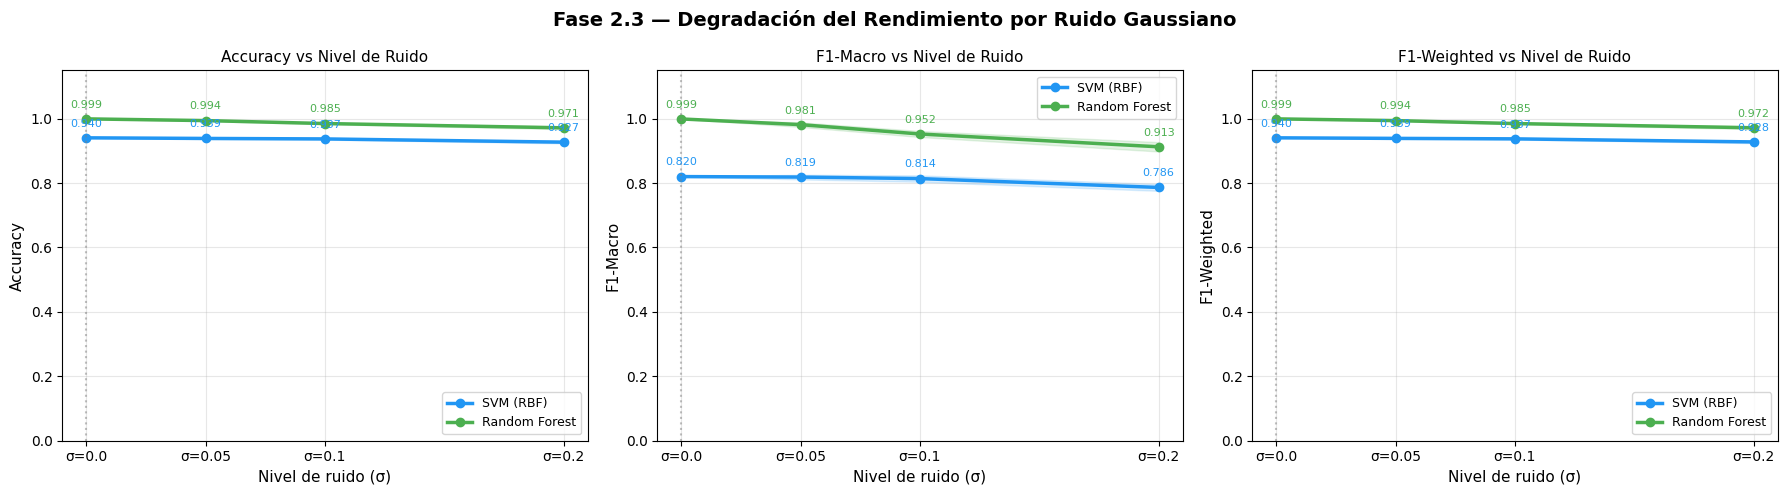

✓ Gráfica guardada en img/ruido_controlado.png


In [ ]:
os.makedirs('../img', exist_ok=True)

colores = {'SVM (RBF)': '#2196F3', 'Random Forest': '#4CAF50'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fase 2.3 — Degradación del Rendimiento por Ruido Gaussiano',
             fontsize=14, fontweight='bold')

metricas = [
    ('Accuracy',    'Acc_std',  'Accuracy'),
    ('F1-Macro',    'F1M_std',  'F1-Macro'),
    ('F1-Weighted', 'F1W_std',  'F1-Weighted'),
]

for ax, (metrica, std_col, titulo) in zip(axes, metricas):
    for nombre, color in colores.items():
        subset = df_ruido[df_ruido['Modelo'] == nombre].sort_values('sigma')
        
        ax.plot(subset['sigma'], subset[metrica],
                marker='o', linewidth=2.5, color=color, label=nombre)
        
        # Banda de desviación estándar
        ax.fill_between(
            subset['sigma'],
            subset[metrica] - subset[std_col],
            subset[metrica] + subset[std_col],
            alpha=0.15, color=color
        )
        
        # Anotar valor en cada punto
        for _, row in subset.iterrows():
            ax.annotate(f"{row[metrica]:.3f}",
                        xy=(row['sigma'], row[metrica]),
                        xytext=(0, 8), textcoords='offset points',
                        ha='center', fontsize=8, color=color)
    
    ax.set_xlabel('Nivel de ruido (σ)', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(f'{titulo} vs Nivel de Ruido', fontsize=11)
    ax.set_xticks(NIVELES_RUIDO)
    ax.set_xticklabels([f'σ={s}' for s in NIVELES_RUIDO])
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('../img/fase2_3_ruido_controlado.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Gráfica de degradación relativa

Muestra cuántos puntos porcentuales pierde cada modelo respecto a su línea base.

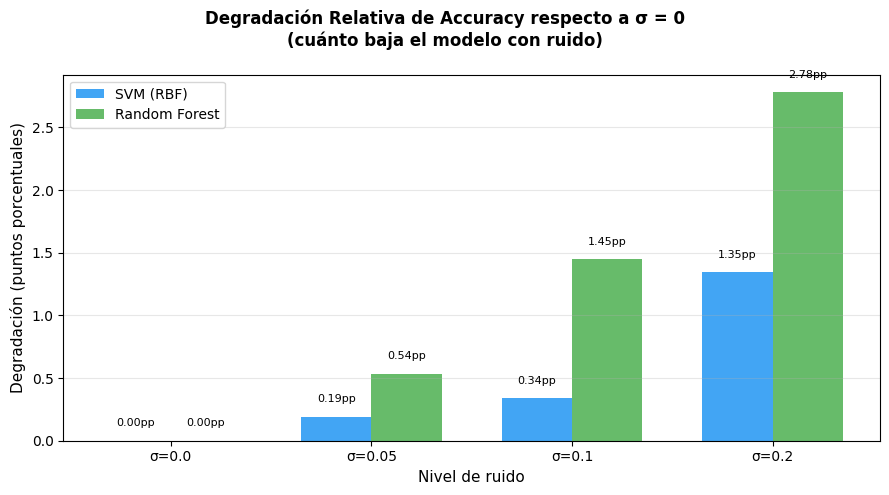

✓ Gráfica guardada en img/degradacion_relativa.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Degradación Relativa de Accuracy respecto a σ = 0\n(cuánto baja el modelo con ruido)',
             fontsize=12, fontweight='bold')

x     = np.arange(len(NIVELES_RUIDO))
width = 0.35

for i, (nombre, color) in enumerate(colores.items()):
    subset = df_ruido[df_ruido['Modelo'] == nombre].sort_values('sigma')
    base   = subset[subset['sigma'] == 0.0]['Accuracy'].values[0]
    degr   = (base - subset['Accuracy'].values) * 100  # en puntos porcentuales
    
    bars = ax.bar(x + i*width, degr, width, label=nombre, color=color, alpha=0.85)
    
    for bar, v in zip(bars, degr):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{v:.2f}pp', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width/2)
ax.set_xticklabels([f'σ={s}' for s in NIVELES_RUIDO])
ax.set_ylabel('Degradación (puntos porcentuales)', fontsize=11)
ax.set_xlabel('Nivel de ruido', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../img/fase2_3_degradacion_relativa.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Interpretación automática

In [ ]:
print('='*65)
print('INTERPRETACIÓN — ROBUSTEZ ANTE RUIDO')
print('='*65)

for nombre in modelos:
    subset = df_ruido[df_ruido['Modelo'] == nombre].sort_values('sigma')
    base   = subset[subset['sigma'] == 0.0]['Accuracy'].values[0]
    peor   = subset[subset['sigma'] == 0.2]['Accuracy'].values[0]
    degr   = (base - peor) * 100
    
    print(f'\n{nombre}:')
    print(f'  Accuracy sin ruido  (σ=0.00): {base:.4f}')
    print(f'  Accuracy con ruido  (σ=0.20): {peor:.4f}')
    print(f'  Degradación total           : {degr:.2f} puntos porcentuales')
    
    if degr < 2:
        print(f'  ✓ MUY ROBUSTO — degradación < 2pp, apto para uso clínico real')
    elif degr < 5:
        print(f'  ~ MODERADAMENTE ROBUSTO — degradación < 5pp, aceptable')
    else:
        print(f'  ✗ SENSIBLE AL RUIDO — degradación > 5pp, requiere preprocesamiento adicional')

# Determinar ganador en robustez
degradaciones = {}
for nombre in modelos:
    subset = df_ruido[df_ruido['Modelo'] == nombre].sort_values('sigma')
    base   = subset[subset['sigma'] == 0.0]['Accuracy'].values[0]
    peor   = subset[subset['sigma'] == 0.2]['Accuracy'].values[0]
    degradaciones[nombre] = (base - peor) * 100

mas_robusto = min(degradaciones, key=degradaciones.get)
print(f'\n→ Modelo más robusto ante ruido: {mas_robusto} '
      f'(degradación de solo {degradaciones[mas_robusto]:.2f}pp con σ=0.20)')



INTERPRETACIÓN — ROBUSTEZ ANTE RUIDO

SVM (RBF):
  Accuracy sin ruido  (σ=0.00): 0.9404
  Accuracy con ruido  (σ=0.20): 0.9270
  Degradación total           : 1.35 puntos porcentuales
  ✓ MUY ROBUSTO — degradación < 2pp, apto para uso clínico real

Random Forest:
  Accuracy sin ruido  (σ=0.00): 0.9993
  Accuracy con ruido  (σ=0.20): 0.9715
  Degradación total           : 2.78 puntos porcentuales
  ~ MODERADAMENTE ROBUSTO — degradación < 5pp, aceptable

→ Modelo más robusto ante ruido: SVM (RBF) (degradación de solo 1.35pp con σ=0.20)
